In [1]:
# WEBCAM DISTANCE ESTIMATION
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
from ultralytics import YOLO

# Depth Anything V2
import sys
from pathlib import Path
repo_path = Path.cwd() / "Depth-Anything-V2"
sys.path.append(str(repo_path))
from depth_anything_v2.dpt import DepthAnythingV2

W0507 10:38:52.947000 11844 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
# Load pretrained YOLO objDet_model
YOLO_version_text = "yolov8n.pt"
objDet_model = YOLO(YOLO_version_text)

In [3]:
# Load Depth Estimation Model (Depth-Anything-V2)
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'
ckpt_path = repo_path / "checkpoints" / f"depth_anything_v2_{encoder}.pth"

depth_model = DepthAnythingV2(**model_configs[encoder])
depth_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
depth_model = depth_model.to(DEVICE).eval()

In [4]:
# Open the camera
cam = cv2.VideoCapture(0)

# Make sure the camera is open
if not cam.isOpened():
    print("The camera isn't opening! :(")
    exit()
    quit()

# Get Frame Dimensions
dims = np.array([int(cam.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cam.get(cv2.CAP_PROP_FRAME_HEIGHT))])
print("Frame Dimensions: [%i, %i]" % (dims[0], dims[1]))

Frame Dimensions: [640, 480]


In [5]:
print('Press "q" or ESC key to quit the application')

def center_crop(img, frac=2):
    h, w = img.shape

    ch, cw = h // frac, w // frac  # crop size

    y0 = h//2 - ch//2
    y1 = h//2 + ch//2
    x0 = w//2 - cw//2
    x1 = w//2 + cw//2

    return ( img[y0:y1, x0:x1], [x0,y0,x1-x0,y1-y0] )

#prepare the 5x5 shaped filter
kernel_large = np.ones((13,13)) / (13**2)
kernel_medium = np.ones((9,9)) / (9**2)
kernel_small = np.ones((5,5)) / (5**2)

# initialize bounding box
x1 = 1
x2 = 2
y1 = 1
y2 = 2

# -------------------------------
write_video = True
if write_video:
    # Video Writer Setup
    fps = 24
    
    # output frame size
    output_size = (dims[0] * 2, dims[1])
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    
    video_writer = cv2.VideoWriter(
        "output1.mp4",
        fourcc,
        fps,
        output_size
    )

# -------------------------------

# Specify Which Object to Look For
object_ID = 32 # 47 = apple, 32 = "apple" "sports ball" # ID number for object in question
print('Looking for "' + objDet_model.names[object_ID] + '"')

fail_count = 0 # failed frame acquisition count
fail_limit = 10 # maximum number of failed frame acquisitions before the program exits

# Camera object search & display loop
while True:
    ret, frame = cam.read()

    # If the frame was successfully captured...
    if ret:
        
        # Estimate Depth
        depth = depth_model.infer_image(frame) # HxW raw depth map in numpy
        # Display Depth
        depth_01 = (depth-np.min(depth))/(np.max(depth)-np.min(depth))
        # cv2.imshow("Depth (0-1 Normalized)", depth_01)
        depth_01_rgb = cv2.cvtColor(depth_01, cv2.COLOR_GRAY2RGB) * 255

        # Run Object Detector on frame image
        results = objDet_model(frame, verbose=False)

        # Get bounding boxes for detected objects (left, top, right, bottom)
        boxes = results[0].boxes

        # Get specific desired object class bounding box
        filtered_boxes = boxes[ (boxes.cls == object_ID) ]

        # Display Bounding Box Rectangle on frame
        for box in filtered_boxes:
            # round bound box corners to pixel index values
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # # Display Rectangle
            # cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.rectangle(depth_01_rgb, (x1, y1), (x2, y2), (0,255,0), 2)


        
        ROI = depth_01[y1:y2, x1:x2]
        subROI, bbox_subROI = center_crop(ROI, frac=3)
        object_distance = np.mean(subROI)

        out_frame = cv2.hconcat([frame, depth_01_rgb.astype(frame.dtype)])
        cv2.imshow("Object Detection on Depth Map", out_frame)
        # cv2.imshow("Object Detection on Depth Map", out_frame)

        # -------------------------------
        # Write Frame Output to Video File
        if write_video:
            video_writer.write(out_frame)
        
    else:
        fail_count += 1
        print("Failed to capture frame from camera")
        if fail_count > fail_limit:
            print("Failed to capture frame from camera %i times, exiting program..." % fail_limit)
            break

    # Press 'q' to exit the loop
    if (cv2.waitKey(1) == ord('q')) or (cv2.waitKey(1) == 27):
        break

# Close Video Writer
if write_video:
    video_writer.release()

# Close Window
cv2.destroyAllWindows()

Press "q" or ESC key to quit the application
Looking for "sports ball"


C:\Users\maxba\anaconda3\envs\ImagingScience\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\maxba\anaconda3\envs\ImagingScience\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
# Release the camera capture object
cam.release()
# Close Windows
cv2.destroyAllWindows()

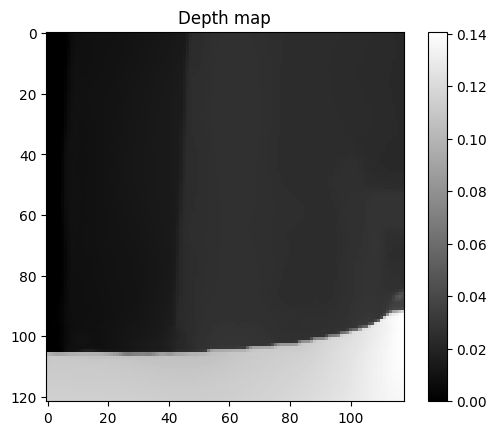

In [7]:
if ret:
    ROI = depth_01[x1:x2, y1:y2]
    dims_ROI = np.array([x2-x1, y2-y1])
    center_pos_ROI = np.array([round((dims_ROI[0]) / 2), round((dims_ROI[1]) / 2)])
    frac = 3
    offset_ROI = np.rint(dims_ROI/frac)
    subROI_bbox = np.r_[(center_pos_ROI - offset_ROI), (center_pos_ROI + offset_ROI)]
    subROI = ROI[int(subROI_bbox[0]):int(subROI_bbox[2]), int(subROI_bbox[1]):int(subROI_bbox[3])]
    
    # Display Depth Image
    plt.imshow(subROI, cmap='gray')
    plt.colorbar()
    plt.title("Depth map")
    plt.show()

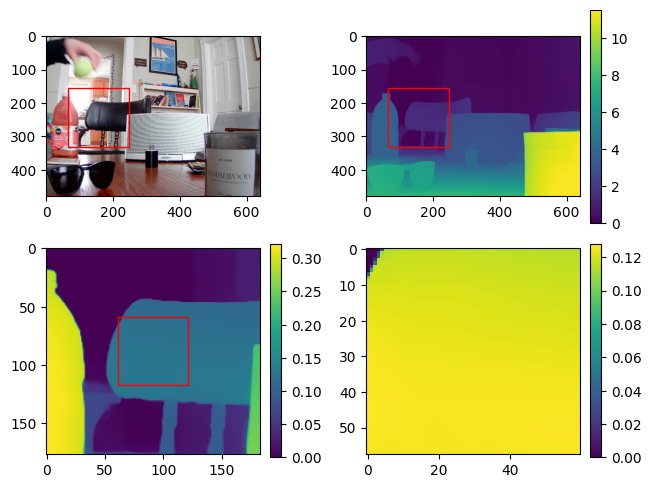

In [8]:
def center_crop(img, frac=2):
    h, w = img.shape

    ch, cw = h // frac, w // frac  # crop size

    y0 = h//2 - ch//2
    y1 = h//2 + ch//2
    x0 = w//2 - cw//2
    x1 = w//2 + cw//2

    return ( img[y0:y1, x0:x1], [x0,y0,x1-x0,y1-y0] )

if ret:
    ROI = depth_01[y1:y2, x1:x2]
    # ROI = depth_01[x1:x2, y1:y2]
    subROI, bbox_subROI = center_crop(ROI, frac=3)
    
    
    
    
    fig, axs = plt.subplots(2, 2, layout="constrained")
    ax1 = axs[0,0].imshow( cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) )
    ax2 = axs[0,1].imshow(depth); plt.colorbar(ax2, ax=axs[0,1])
    ax3 = axs[1,0].imshow(ROI); plt.colorbar(ax3, ax=axs[1,0])
    ax4 = axs[1,1].imshow(subROI); plt.colorbar(ax4, ax=axs[1,1])
    axs[0,0].add_patch( patches.Rectangle((x1, y1), dims_ROI[0], dims_ROI[1], linewidth=1, edgecolor='r', facecolor='none') )
    axs[0,1].add_patch( patches.Rectangle((x1, y1), dims_ROI[0], dims_ROI[1], linewidth=1, edgecolor='r', facecolor='none') )
    axs[1,0].add_patch( patches.Rectangle((bbox_subROI[0], bbox_subROI[1]), bbox_subROI[2], bbox_subROI[3], linewidth=1, edgecolor='r', facecolor='none') )
    plt.show()

In [9]:
if ret:
    # Calculate Image Distance
    focal_length = 35 # focal length of lens <mm>
    object_distance = np.mean(subROI)
    image_distance = (focal_length * object_distance) / (object_distance - focal_length)
    print("Focal Length = %imm, Object Distance = %.2f, Image Distance = %.2f" % (focal_length, object_distance, image_distance))

Focal Length = 35mm, Object Distance = 0.12, Image Distance = -0.12
